# Example 1 — Attitude Control of a Spacecraft

This example demonstrates the development of a spacecraft simulation focused on rotational dynamics and attitude control.

## Notes and repository setup

Initial imports and repository path configuration used by the example.

In [15]:
import numpy as np
from pathlib import Path
import sys

path = Path.cwd()

REPO_ROOT = path.parents[2]

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

## General Simulation Setup

ARGOS can work with multiple spacecraft at a time; however, before defining any spacecraft, we need to define a common simulation setup.

### Environment

The environment object provides the simulation environment in which the spacecraft dynamics are evaluated.

In [16]:
from py.modules.enviroments.environments import ClassicalEnvironment

env = ClassicalEnvironment()

### Simulation setup

The `Simulation` object defines the overall simulation horizon and environment. This works as a central orchestrator for each spacecraft that will be added to the sim.

*Note: All the units in the simulations are in the International Metric System.*

In [18]:
from py.modules.core.simulation import Simulation

sim = Simulation(max_sim_time=5*60, # 3 minutes,                 
                 environment= env,                 
                 verbose = True
)

## Spacecraft Creation

To create a spacecraft, several things need to be defined depending on the level of detail desired. The things included are:

- Actuators
- Sensors
- Mission Manager
- Target

In the following example, we will address the basic definitions and creation of the first three items.

### Actuators

Actuators will introduce external forces and torques into the simulation. The actuators could either be controllable or not.

For example, a solid rocket motor will not be controllable, while RCS thrusters are.

In this case, as we are addressing an attitude control problem, a set of RCS thrusters will be defined.

#### RCS Thruster

The RCS Thruster class is intended to replicate the principal functional and operational capabilities of a real RCS thruster.

Therefore, if we want full authority in the 3 DOFs and the 2 directions in each axis, we need a total of 6 thrusters.

Although the class supports a position definition for the thruster (and, based on that, calculates the torque exerted about the CG), in preliminary designs, the position may not be available, but the torque is still desired. In those cases, we cannot define the position, but we can define a torque value that will automatically override the internal calculation output (which will be zero due to the lack of a position definition).

Note that the class also allows different command methods; by default, we have a PWM method.

In [19]:
from py.modules.actuators.RCS import RCSThruster

thruster_X_pos = RCSThruster(
    nominal_thrust= 0,
    direction= np.array([1, 0, 0]),
    override_torque_value = 300,
    modulation_window= 0.1,
    minimum_on_time= 0.01,
    activation_threshold= 0.0
)

thruster_X_neg = RCSThruster(
    nominal_thrust= 0,
    direction= np.array([-1, 0, 0]),
    override_torque_value = 300,
    modulation_window= 0.1,
    minimum_on_time= 0.01,
    activation_threshold= 0.0
    
)

thruster_Y_pos = RCSThruster(
    nominal_thrust= 0,
    direction= np.array([0, 1, 0]),
    override_torque_value = 300,
    modulation_window= 0.1,
    minimum_on_time= 0.01,
    activation_threshold= 0.0
)

thruster_Y_neg = RCSThruster(
    nominal_thrust= 0,
    direction= np.array([0, -1, 0]),
    override_torque_value = 300,
    modulation_window= 0.1,
    minimum_on_time= 0.01,
    activation_threshold= 0.0
)

thruster_Z_pos = RCSThruster(
    nominal_thrust= 0,
    direction= np.array([0, 0, 1]),
    override_torque_value = 300,
    modulation_window= 0.1,
    minimum_on_time= 0.01,
    activation_threshold= 0.0   
)

thruster_Z_neg = RCSThruster(
    nominal_thrust= 0,
    direction= np.array([0, 0, -1]),
    override_torque_value = 300,
    modulation_window= 0.1,
    minimum_on_time= 0.01,
    activation_threshold= 0.0
)

thrusters = [thruster_X_pos, thruster_X_neg, thruster_Y_pos, thruster_Y_neg, thruster_Z_pos, thruster_Z_neg]

As mentioned later, an actuator can be controllable (or not). It can be available or not (for example, in a two-stage rocket with solid motors, the second-stage motor could be available but not be active, and once we get there, both stages' motors will not be available as they are single-use), and therefore, we can also see if the actuator has been used. We can access this information with the following methods:

In [20]:
print(thruster_Z_neg.is_available())
print(thruster_Z_neg.has_been_used())
print(thruster_Z_neg.is_controllable())

True
False
True


Or access more general information with

In [21]:
thruster_X_pos.print_information()

RCS Thruster Information:
Is controllable: True
Is available: True
Has been used: False
Nominal Thrust: 0 N
Position: [0. 0. 0.]
Direction: [1. 0. 0.]
Command Mode: PWM
Modulation Window: 0.1 s
Minimum On Time: 0.01 s
Activation Threshold: 0.0 N
Override Torque Enabled: Yes
Override Torque Value: 300 Nm


### Sensors

Sensors are a key item in any system, especially when any type of control is desired.

Various sensor types are defined; however, in this example, we will not cover them.

However, as we are proposing a control system, and in general, anytime we want to evaluate the performance of a control or guidance algorithm, we want to test them with the real/perfect data.

In those cases, we can use the AbsoluteSensor, which will simply "copy-paste" the true state variables, which are the dynamically integrated variables.

For any sensor, we need to define a Sample Rate in Hz, which will define the interval at which the sensor will update the data it is measuring.

In [22]:
from py.modules.sensors.generic_sensor import AbsoluteSensor

sensors = [AbsoluteSensor(100, verbose=False)]  # Sample rate of 100 Hz

### Mission Manager

All spacecraft need a mission manager. This class, as its name indicates, will store different mission phases.

A phase is basically a portion of the whole simulation where different GNC laws or propagators are needed.

For example, we can have a nominal phase, where certain GNC laws are used, and an off-nominal phase, where the GNC laws change.

In that same way, when multiple phases are defined, transitions need to be defined. This will not be covered here, but is covered in Example 4.

#### Mission Phase

As mentioned, the mission phase will have (or not) different GNC laws and propagators defined. Therefore, to create a phase, we first need to define the items that will be used in that specific phase.

##### Propagators

The propagator defines the dynamical model and numerical integration method used by the simulation. A translational propagator and a rotational propagator can be defined independently. In this case, as we are defining a rotational example, the translational propagator will be ignored.

By default, the `NativeRotationalPropagator` uses the Euler equations with quaternions.

This will be added later to a mission phase.

In [23]:
from py.modules.propagators.native_propagator import NativeRotationalPropagator

rot_propagator = NativeRotationalPropagator(integration_method="NATIVE_RK45")

##### Guidance

If any control is desired, a guidance law is needed, as this will set the reference variables that the controller will follow.

A custom guidance law can be defined using the `CustomGuidanceLaw` class. This class will have access to the `navigation_estimated` data (which will be covered in the next step) and the information of the simulation, and it is required to return a `GuidanceOutput` dataclass.

In [24]:
# Next step is define the guidance law
from py.modules.general.dataclasses import GuidanceOutput, StateVariables
from py.modules.guidance.basic_laws import CustomGuidanceLaw
from py.modules.math import quaternion_from_euler

objective_orientation = [0, 0, 0]  # Desired orientation in Euler angles (degrees)


def compute_reference(navigation_estimated_data, simulation_data):

    ref = GuidanceOutput(
        state=StateVariables(
            attitude=quaternion_from_euler(
                np.deg2rad(objective_orientation[0]),
                np.deg2rad(objective_orientation[1]),
                np.deg2rad(objective_orientation[2]),
            )
        )
    )
    return ref

guidance_law = CustomGuidanceLaw(
    custom_reference_function= compute_reference
)

However, some guidance laws are already implemented, such as a constant reference guidance law, which is the one that we need in this example, as throughout the whole phase, the reference will be the same.

In [25]:
from py.modules.guidance.basic_laws import ConstantReferenceGuidance

guidance_law = ConstantReferenceGuidance(
    desired_quat = quaternion_from_euler(np.deg2rad(objective_orientation[0]), np.deg2rad(objective_orientation[1]), np.deg2rad(objective_orientation[2]))
)

##### Navigation

If a guidance law is being used, then it is mandatory to have a navigation law. However, it is not mandatory the other way around, as sometimes it is only desired to test filters and estimation algorithms.

Similar to the guidance law, it is possible to define custom navigation laws using the `CustomNavigation` class. For this, the input will be only the sensors that the spacecraft has; therefore, you will not have access to the real/true states (unless you define an Absolute Sensor).

In [26]:
from py.modules.general.dataclasses import NavigationOutput
from py.modules.navigation.basic_laws import CustomNavigation

def estimate(sensors):

    for sensor in sensors:
        if sensor.type   == "AbsoluteSensor":
            sensor_data = sensor.get_measurement()                

            estimated_attitude = sensor_data[0][3]
            estimated_angular_velocity = sensor_data[0][4]            

            return NavigationOutput(
                spacecraft_attitude=estimated_attitude,
                spacecraft_angular_velocity=estimated_angular_velocity
            )                

navigation_law = CustomNavigation(
    custom_estimation_function=estimate
)

Again, there are some already defined navigation laws. As we initially talked about not using any sensor model, but using the Absolute Sensor to test the control law, we need to keep the same philosophy here. Therefore, an Ideal Navigation law is already implemented, which will automatically translate the real/true states into the estimation output (that is used both in the reference/guidance module and in the control module).

In [27]:
from py.modules.navigation.basic_laws import IdealNavigation

navigation_law = IdealNavigation()  # Using the ideal navigation law for this example

##### Control

The control module works similarly to the guidance and navigation modules, being able to define a fully custom model or use one of the already implemented laws.

In this case, we will use a PD Attitude Controller.

In [28]:
from py.modules.controllers.classic_controllers import PDAttitudeController

control_law = PDAttitudeController(
    proportional_gain= 1000,
    derivative_gain= 20000,
    maximum_torque= 1000,
    minimum_torque= -1000
)

##### Control allocation

As the control module will just generate the control reference (in both force and torque needed to achieve the guidance law), we need an allocation algorithm that will translate that need into a physical allocation among the defined actuators.

Once again, custom and already implemented methods can be used, as shown:

In [29]:
from py.modules.controllers.basic_laws import CustomControlAllocator

def allocate(control_output, actuators):
    
    torque_to_allocate = control_output.torque

    # Extract direction and magnitude of the torque to allocate
    torque_magnitude = np.linalg.norm(torque_to_allocate)
    torque_direction = torque_to_allocate / torque_magnitude if torque_magnitude != 0 else np.zeros(3)
    
    for actuator in actuators:
        # Calculate the dot product between the actuator's direction and the torque direction
        dot_product = np.dot(actuator.direction, torque_direction)
        # If the dot product is positive, the actuator can contribute to the torque
        if dot_product > 0:
            # Allocate a portion of the torque to this actuator based on its direction
            allocated_torque = dot_product * torque_magnitude
            #print(f"Allocating torque {allocated_torque} to actuator with direction {actuator.direction}")
            # Set the actuator's command based on the allocated torque                
            actuator.set_command(allocated_torque)
        else:
            # If the actuator cannot contribute, set its command to zero
            actuator.set_command(0)

allocator_law = CustomControlAllocator(
    allocation_function= allocate
)

The same basic algorithm previously shown is implemented in the `BasicRCSAllocator`, which will assume 6 RCS thrusters where the torque will be allocated.

In [30]:
from py.modules.controllers.basic_laws import BasicRCSAllocator

allocator_law = BasicRCSAllocator()

##### Mission phase and mission manager definition

As all the minimum things are already defined, we can move on to create the mission phase and mission manager objects.

For the mission phase, in addition to the previously discussed items, we need to provide a unique name for the phase and the update rates for each of the laws and propagators in seconds.

In [31]:
from py.modules.general.dataclasses import MissionPhase

phase = MissionPhase(
    name="SinglePhase",
    guidance= guidance_law,
    navigation= navigation_law,
    controller= control_law,

    allocator = allocator_law,

    dt_nav = 0.1,  # Navigation update rate (10 Hz)
    dt_guid = 1,  # Guidance update rate (1 Hz)
    dt_control = 0.1, # Control update rate (10 Hz)

    rotational_model= rot_propagator,
    dt_propagation= 0.01 # Propagation time step (100 Hz)
)

With that, we can set this phase as the initial phase in the mission manager. In this example, it is not covered how to add phases and transitions; this is covered in Example 4.

In [32]:
from py.modules.core.mission_manager import MissionManager

mission_manager = MissionManager(
    initial_phase= phase
)

### Spacecraft initialization

With all the previous steps completed, we can now move on to creating the spacecraft, where the inertial parameters need to be added, as well as the initial conditions and all the three previous elements.

In [35]:
# With all this, we can now add an spacecraft to the sim
from py.modules.math import quaternion_from_euler
from py.modules.general.general_data import Ix_total, Iy_total, Iz_total

initial_vel = np.array([0.0, 0.0, 0.0])  # Initial velocity in meters per second
initial_orientation = initial_orientation = [45, -30, -10]  # Initial orientation in Euler angles (degrees)
initial_orientation_quat = quaternion_from_euler(np.deg2rad(initial_orientation[0]), np.deg2rad(initial_orientation[1]), np.deg2rad(initial_orientation[2]))
initial_angular_velocity = np.array([-0.08, 0.05, 0.1])  # Initial angular velocity in rad/s

sim.add_spacecraft(    
    initial_attitude= initial_orientation_quat,
    initial_angular_velocity= initial_angular_velocity,
    inertia_tensor= np.diag([Ix_total, Iy_total, Iz_total]),  # Inertia tensor in kg*m^2
    actuators = thrusters,
    sensors = sensors,
    mission_manager = mission_manager,
    verbose = True
)

Mass not provided. Using default mass of 0 kg.
Initial position not provided. Using default position of [0, 0, 0].
Initial velocity not provided. Using default velocity of [0, 0, 0].
[INFO] Spacecraft 'Spacecraft_1' history initialized. Data will be saved in 'tmp/simulation_1790562624243'.
========== Spacecraft created successfully. ==========
Spacecraft Name: Spacecraft_1
Mass: 0.0 kg
Inertia Tensor: 
[[80921.72163479     0.             0.        ]
 [    0.         80921.72163479     0.        ]
 [    0.             0.         61091.        ]]
NOT IMPLEMENTED: GNC information display is not yet implemented.
NOT IMPLEMENTED: Spacecraft state information display is not yet implemented.
========== End of spacecraft information. ==========
Spacecraft 'Spacecraft_1' added to the simulation.


### Simulation execution and results

Now the simulation can be executed.

In [36]:
# We can now simulate
metadata = sim.simulate()

Initializing simulation...
Spacecraft 'Spacecraft_1' dt_nav: 0.1, dt_guid: 1, dt_control: 0.1
Simulation initialized.
Starting simulation...
Simulation completed.


The results of the simulation can be accessed via the result variable. For more information on the data format of the result, check `dataSave` class documentation.

Some plotting functions are already defined, as shown below.

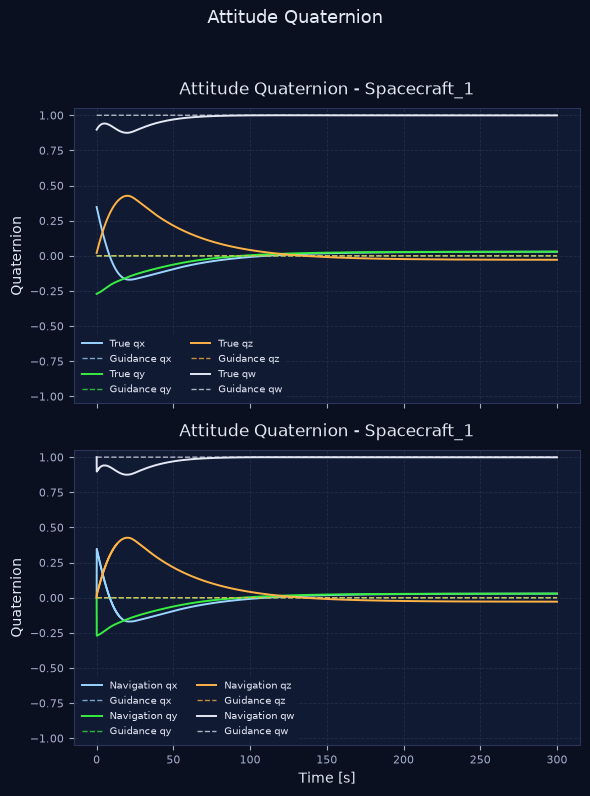

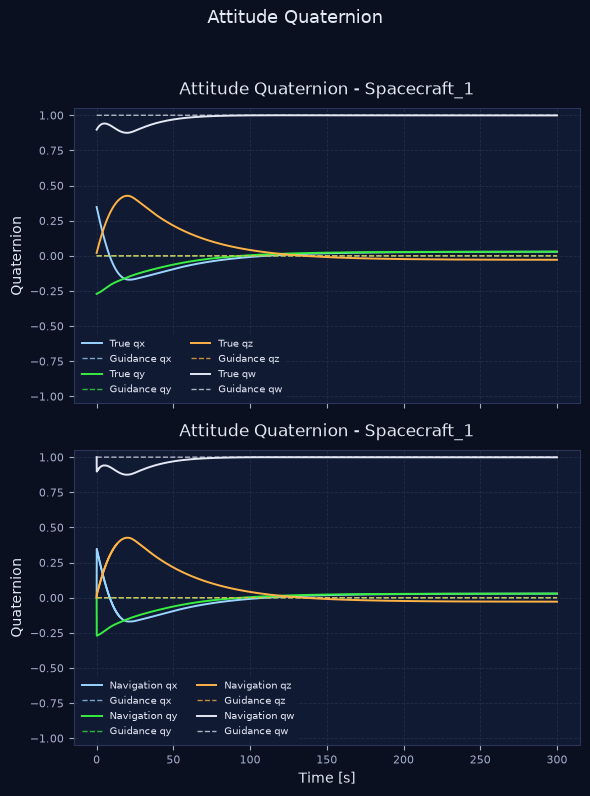

In [37]:
from py.modules.visualization.state_variables import plot_attitude_quaternions, plot_angular_velocity, plot_position
from py.modules.visualization.gnc import plot_control_result

plot_attitude_quaternions("Spacecraft_1", metadata)

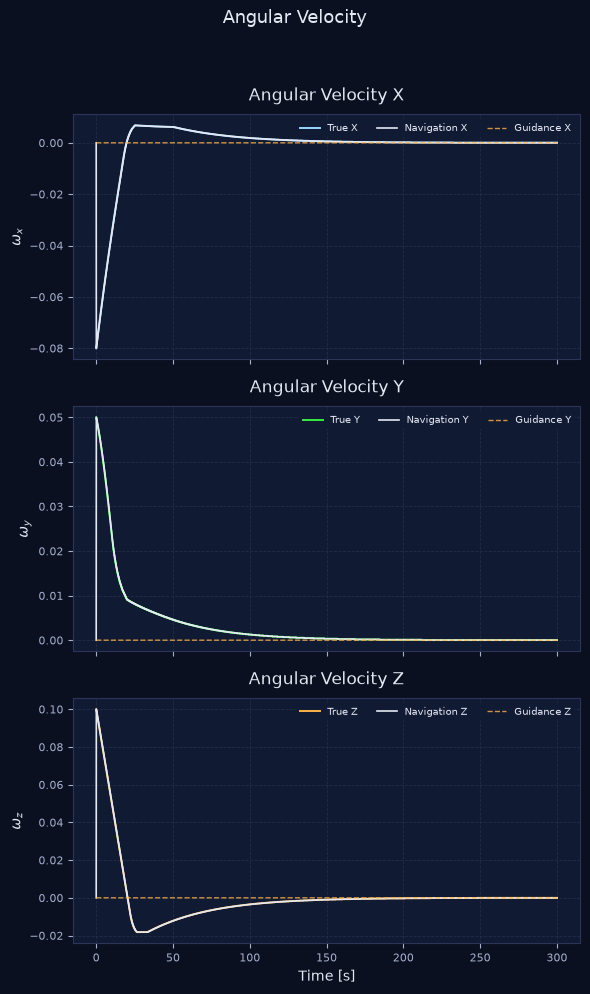

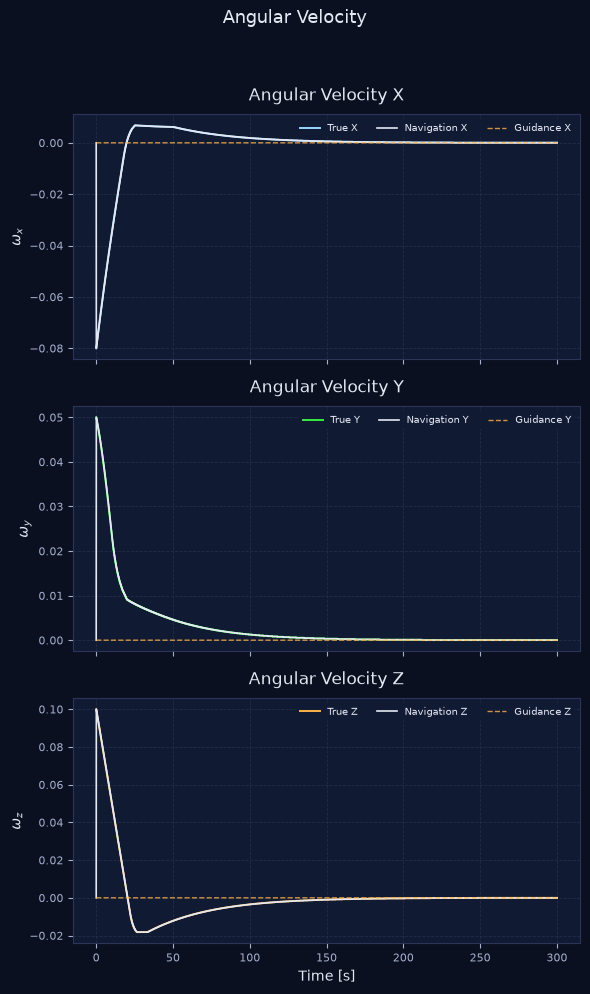

In [38]:
plot_angular_velocity("Spacecraft_1", metadata)

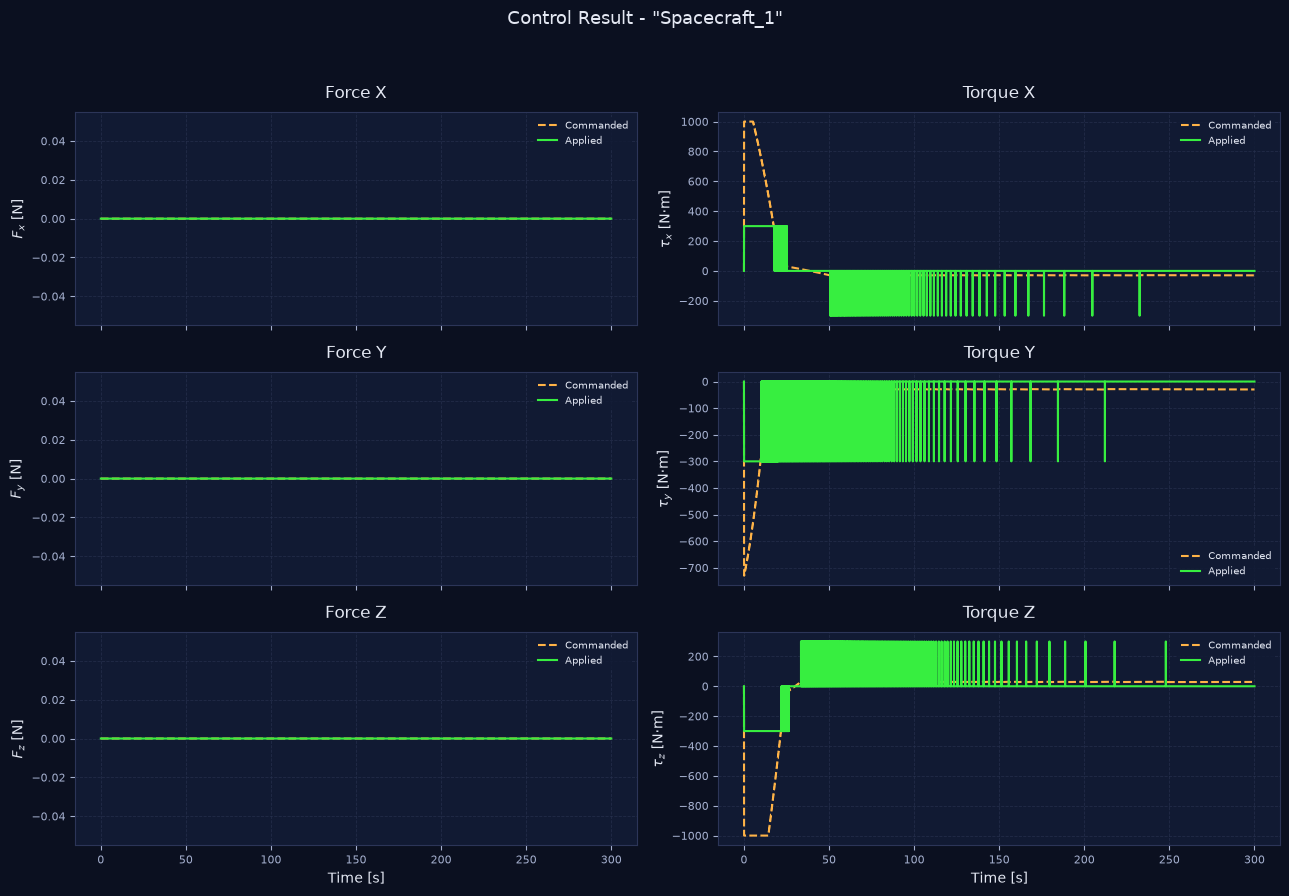

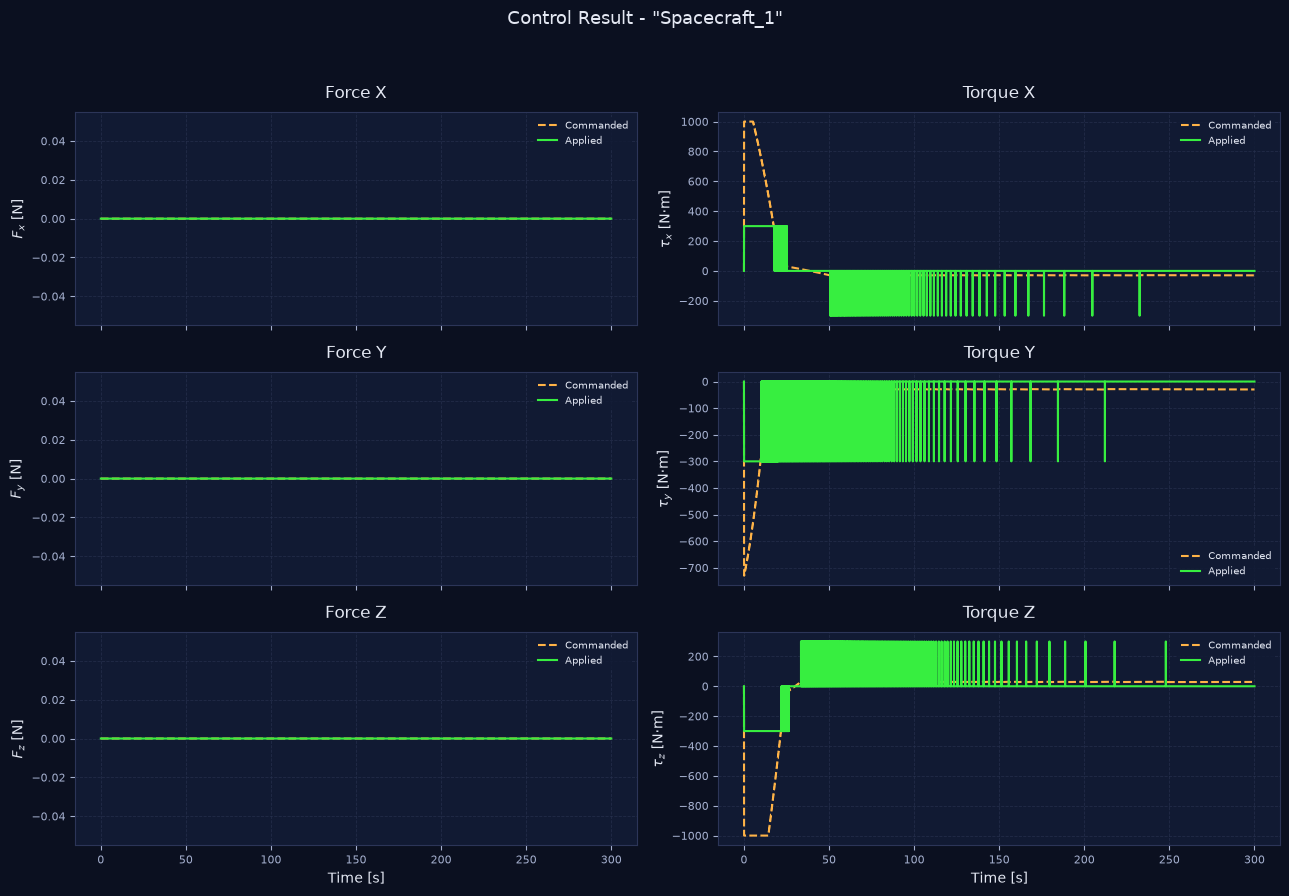

In [39]:
plot_control_result("Spacecraft_1", metadata)

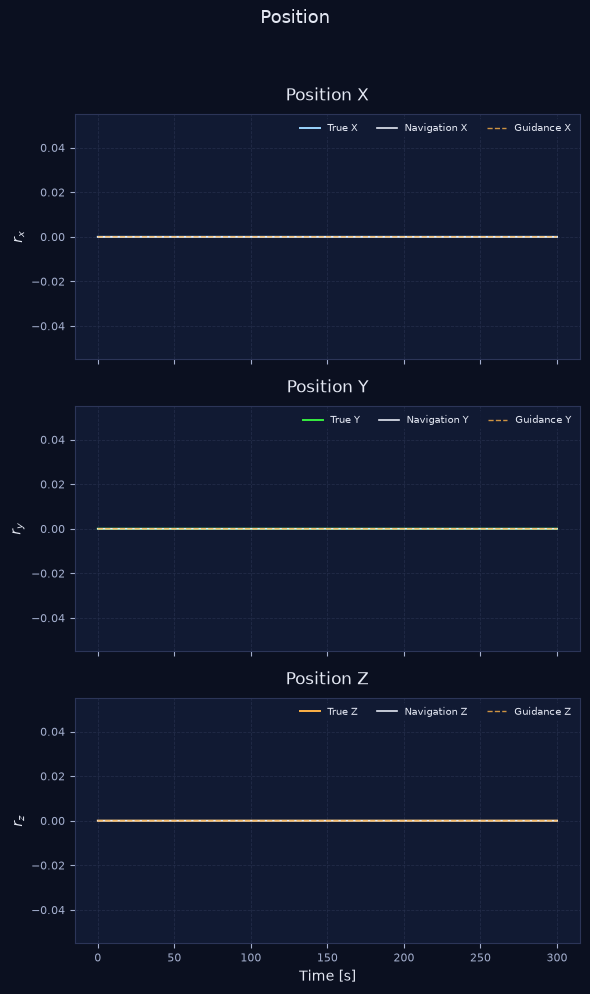

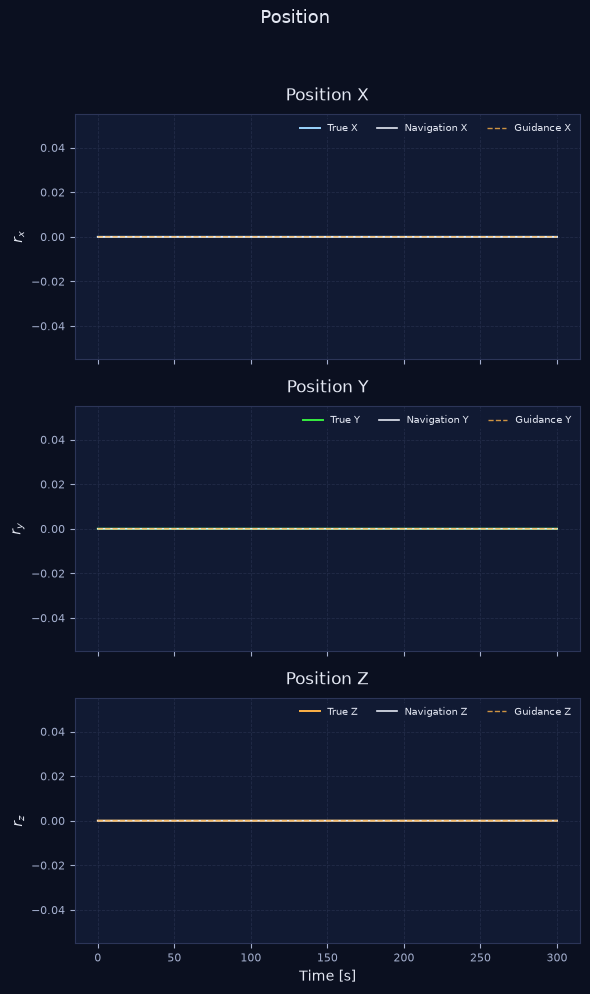

In [40]:
plot_position("Spacecraft_1", metadata)